PROYECTO FINAL CODERHOUSE: MORTALIDAD INFANTIL 2024

En este colab, trabajamos con datos extraidos del sitio wed de la Direccion de Estadísticas e información de salud del Estado argentino. Lo que buscamos es analizar datos sobre mortalidad infantil del año 2024; lo que buscaremos con ello es ver la incidencia de la mortalidad infantil (del día 0 del nacido vivo hasta el año de vida) en cada provincia de la República, y partir de ello, disgregarlo segun la etapa de la defuncion (neonatal o posneonatal) tasa de defuncion de cada una.

**VARIABLES**
- VD: malformaciones congenitas y otras
- VI: Provincias; supgrupo etario


OBJETIVO
El presente trabajo tiene dos objetivos complementarios. Por un lado, desarrollar un modelo de clasificación que permita predecir si una defunción infantil por malformación congénita corresponde a una cardiopatía congénita (Q20-Q28) o a otra malformación congénita, en función del subgrupo etario y la provincia de residencia. Por otro lado, analizar la tasa de mortalidad infantil por provincia y región geográfica, con el fin de identificar desigualdades territoriales en el acceso a la salud materno-infantil en Argentina durante el año 2024.

CONTEXTO COMERCIAL
El Ministerio de Salud de la Nación ha identificado un aumento en la tasa de mortalidad infantil en el último relevamiento demográfico correspondiente al año 2024 (aumento registrado de 0,5 puntos más respecto de 2023). Ante este escenario, surge la necesidad de analizar en profundidad las causas de muerte en menores de un año, con foco en las malformaciones congénitas, que representan la segunda causa de mortalidad infantil en Argentina. El análisis busca brindar información que oriente la toma de decisiones en materia de políticas públicas de salud, priorizando la detección prenatal de cardiopatías congénitas y la reducción de las brechas regionales existentes.

HIPÓTESIS
"Un modelo de aprendizaje automático podrá clasificar con precisión las defunciones infantiles por malformación congénita en cardiopatías congénitas o en otras malformaciones, a partir del subgrupo etario y la provincia de residencia, esperando alcanzar un F1-score superior a 0.70. Asimismo, se espera evidenciar patrones de desigualdad territorial, con tasas de mortalidad infantil por malformaciones congénitas significativamente más elevadas en las regiones NOA y NEA respecto de las regiones Pampeana y Patagónica."

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [7]:
tabla = '/content/drive/MyDrive/coderhouse/datos_sobre_defunciones_2024.csv'

In [8]:
df = pd.read_csv(tabla, sep=';', encoding='latin1')

In [9]:
# CELDA — Exploración inicial
print('=== DIMENSIONES ===')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print()
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print()
print('=== VALORES NULOS ===')
print(df.isnull().sum())
print()
print('=== PRIMERAS FILAS ===')
df.head(10)

=== DIMENSIONES ===
Filas: 54251
Columnas: 6

=== TIPOS DE DATOS ===
ï»¿PROVRES     int64
SEXO           int64
CAUSA         object
MAT           object
GRUPEDAD      object
CUENTA         int64
dtype: object

=== VALORES NULOS ===
ï»¿PROVRES        0
SEXO              0
CAUSA             0
MAT           54056
GRUPEDAD          0
CUENTA            0
dtype: int64

=== PRIMERAS FILAS ===


,ï»¿PROVRES,SEXO,CAUSA,MAT,GRUPEDAD,CUENTA
0,2,1,A16,NaN,10.15 a 19,2
1,2,1,A16,NaN,12.25 a 29,1
2,2,1,A16,NaN,20.65 a 69,3
3,2,1,A16,NaN,24.85 y mÃ¡s,2
4,2,1,A41,NaN,03.28 dÃ­as a 11 meses,1
5,2,1,A41,NaN,11.20 a 24,2
6,2,1,A41,NaN,13.30 a 34,4
7,2,1,A41,NaN,17.50 a 54,18
8,2,1,A41,NaN,18.55 a 59,39
9,2,1,A41,NaN,21.70 a 74,101


DATOS NULOS *MAT* **texto en negrita**
En la primera visulizacion de nuestro dataset, visualizamos varios valores de MAT que son nulos. No hay ningún caso con M, T o S dentro de las malformaciones congénitas infantiles.
Esto tiene lógica epidemiológica — La dimension MAT registra muerte materna, y estamos trabajando con defunciones de bebés, no de madres.

In [10]:
df = df.rename(columns={'ï»¿PROVRES': 'PROVRES'})

# CELDA — Estadísticas descriptivas PROVRES
print('=== ESTADÍSTICAS PROVRES ===')
print(df['PROVRES'].describe())

# CELDA — Estadísticas descriptivas SEXO
print('=== ESTADÍSTICAS SEXO ===')
print(df['SEXO'].describe())

# CELDA — Estadísticas descriptivas CAUSA
print('=== ESTADÍSTICAS CAUSA ===')
print(df['CAUSA'].describe())

# CELDA — Estadísticas descriptivas MAT
print('=== ESTADÍSTICAS MAT ===')
print(df['MAT'].describe())

# CELDA — Estadísticas descriptivas GRUPEDAD
print('=== ESTADÍSTICAS GRUPEDAD ===')
print(df['GRUPEDAD'].describe())

# CELDA — Estadísticas descriptivas CUENTA
print('=== ESTADÍSTICAS CUENTA ===')
print(df['CUENTA'].describe())

=== ESTADÍSTICAS PROVRES ===
count    54251.000000
mean        42.774695
std         30.287531
min          2.000000
25%         14.000000
50%         42.000000
75%         70.000000
max         99.000000
Name: PROVRES, dtype: float64
=== ESTADÍSTICAS SEXO ===
count    54251.000000
mean         1.468655
std          0.541060
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: SEXO, dtype: float64
=== ESTADÍSTICAS CAUSA ===
count     54251
unique     1053
top         J18
freq        723
Name: CAUSA, dtype: object
=== ESTADÍSTICAS MAT ===
count     195
unique      2
top         M
freq      152
Name: MAT, dtype: object
=== ESTADÍSTICAS GRUPEDAD ===
count            54251
unique              26
top       24.85 y mÃ¡s
freq              5597
Name: GRUPEDAD, dtype: object
=== ESTADÍSTICAS CUENTA ===
count    54251.000000
mean         6.938213
std         48.774746
min          1.000000
25%          1.000000
50%          1.000000


In [11]:
# CELDA 3 — Variables auxiliares
mapa_provincias = {
    2: 'CABA', 6: 'Bs.As', 42: 'La Pampa', 14: 'Córdoba', 82: 'Santa Fe',
    10: 'Catamarca', 90: 'Tucumán', 86: 'Santiago del Estero', 38: 'Jujuy',
    66: 'Salta', 22: 'Chaco', 34: 'Formosa', 30: 'Entre Ríos', 18: 'Corrientes',
    54: 'Misiones', 26: 'Chubut', 58: 'Neuquén', 62: 'Río Negro',
    78: 'Santa Cruz', 94: 'Tierra del Fuego', 70: 'San Juan',
    74: 'San Luis', 50: 'Mendoza', 46: 'La Rioja'
}

mapa_regiones = {
    'Jujuy': 'NOA', 'Salta': 'NOA', 'Tucumán': 'NOA',
    'Catamarca': 'NOA', 'Santiago del Estero': 'NOA',
    'Formosa': 'NEA', 'Chaco': 'NEA',
    'Corrientes': 'NEA', 'Misiones': 'NEA',
    'Mendoza': 'Cuyo', 'San Juan': 'Cuyo',
    'San Luis': 'Cuyo', 'La Rioja': 'Cuyo',
    'Córdoba': 'Pampeana', 'Santa Fe': 'Pampeana',
    'Entre Ríos': 'Pampeana', 'La Pampa': 'Pampeana',
    'Bs.As': 'Pampeana', 'CABA': 'Pampeana',
    'Neuquén': 'Patagónica', 'Río Negro': 'Patagónica',
    'Chubut': 'Patagónica', 'Santa Cruz': 'Patagónica',
    'Tierra del Fuego': 'Patagónica'
}

grupos_infantiles = [
    '01.0 a 6 días',
    '02.7 a 27 días',
    '03.28 días a 11 meses',
    '04.1 año',
    '031. Menor de 1 año  Sin especificar'
]

mapa_subgrupo = {
    '01.0 a 6 días':                       'neonatal_precoz',
    '02.7 a 27 días':                      'neonatal_tardio',
    '03.28 días a 11 meses':               'postneonatal',
    '04.1 año':                            'postneonatal',
    '031. Menor de 1 año  Sin especificar': 'postneonatal'
}

codigos_cardiopatias = [f'Q{i}' for i in range(20, 29)]

codigos_otras = (
    ['Q00', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07'] +
    [f'Q{i}' for i in range(31, 46)] +
    [f'Q{i}' for i in range(60, 66)] +
    ['Q74', 'Q75', 'Q76', 'Q77', 'Q78', 'Q79', 'Q82', 'Q85', 'Q87', 'Q89'] +
    ['Q90', 'Q91', 'Q92', 'Q93', 'Q97', 'Q98', 'Q99']
)

todos_los_codigos_Q = codigos_cardiopatias + codigos_otras

In [12]:
def procesar_csv(file_path):
    # 1. Detectar separador
    with open(file_path, 'r', encoding='latin1') as f:
        primera_linea = f.readline()
    sep = ';' if primera_linea.count(';') > primera_linea.count(',') else ','

    # 2. Leer archivo
    try:
        df = pd.read_csv(file_path, sep=sep, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, sep=sep, encoding='latin1')

    # 3. Eliminar MAT
    if 'MAT' in df.columns:
        df = df.drop(columns=['MAT'])

    # 4. Filtrar mortalidad infantil
    df = df[df['GRUPEDAD'].isin(grupos_infantiles)].copy()

    # 5. Filtrar causas Q
    df = df[df['CAUSA'].isin(todos_los_codigos_Q)].copy()

    # 6. Filtrar SEXO válido
    df = df[df['SEXO'].isin([1, 2])].copy()

    # 7. Filtrar provincias y mapear nombres
    df = df[df['PROVRES'].isin(mapa_provincias.keys())].copy()
    df['PROVINCIA'] = df['PROVRES'].map(mapa_provincias)
    df = df.drop(columns=['PROVRES'])

    # 8. Agregar región
    df['REGION'] = df['PROVINCIA'].map(mapa_regiones)

    # 9. Subgrupo etario
    df['PER_DEF'] = df['GRUPEDAD'].map(mapa_subgrupo)

    # 10. TARGET binario
    df['ENFERMEDAD'] = df['CAUSA'].apply(
        lambda x: 'cardiopatias' if x in codigos_cardiopatias else 'otras_malformaciones'
    )

    # 11. Renombrar columnas
    df = df.rename(columns={
        'SEXO':    'GENERO',
        'CUENTA':  'CANTIDAD',
        'GRUPEDAD': 'EDAD_DEF'
    })

    # 12. Eliminar columna GENERO
    df = df.drop(columns=['GENERO'])

    # 13. Limpiar prefijo numérico de EDAD_DEF
    df['EDAD_DEF'] = df['EDAD_DEF'].str.replace(r'^\d+\.\s*', '', regex=True)

    return df

In [13]:
# CELDA 5 — Ejecutar y verificar
df = procesar_csv(tabla)
print(f"Filas: {len(df)}")
print(f"Columnas: {list(df.columns)}")
print()
print("CAUSA:")
print(df['CAUSA'].value_counts())
print()
print("PROVINCIAS:")
print(df['PROVINCIA'].value_counts())
df.head(20)

Filas: 611
Columnas: ['CAUSA', 'EDAD_DEF', 'CANTIDAD', 'PROVINCIA', 'REGION', 'PER_DEF', 'ENFERMEDAD']

CAUSA:
CAUSA
Q24    82
Q89    58
Q79    45
Q25    37
Q91    32
Q04    29
Q20    29
Q21    27
Q03    24
Q33    23
Q90    21
Q23    19
Q39    19
Q87    18
Q60    14
Q22    14
Q00    13
Q43    13
Q99    12
Q61    11
Q05     9
Q41     8
Q44     5
Q78     5
Q26     5
Q77     4
Q75     4
Q01     4
Q28     4
Q32     3
Q42     2
Q31     2
Q07     2
Q74     2
Q45     2
Q63     2
Q34     2
Q98     1
Q92     1
Q27     1
Q02     1
Q64     1
Q93     1
Name: count, dtype: int64

PROVINCIAS:
PROVINCIA
Bs.As                  123
Santa Fe                48
Córdoba                 47
Mendoza                 38
Chaco                   37
Corrientes              36
Misiones                32
CABA                    29
Tucumán                 29
Salta                   23
San Juan                22
Entre Ríos              21
Santiago del Estero     20
Formosa                 18
Neuquén                 16

,CAUSA,EDAD_DEF,CANTIDAD,PROVINCIA,REGION,PER_DEF,ENFERMEDAD
386,Q24,0 a 6 días,1,CABA,Pampeana,neonatal_precoz,cardiopatias
387,Q25,7 a 27 días,1,CABA,Pampeana,neonatal_tardio,cardiopatias
388,Q33,0 a 6 días,1,CABA,Pampeana,neonatal_precoz,otras_malformaciones
390,Q90,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones
391,Q98,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones
802,Q90,7 a 27 días,1,CABA,Pampeana,neonatal_tardio,otras_malformaciones
804,Q91,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones
1234,Q20,28 días a 11 meses,2,CABA,Pampeana,postneonatal,cardiopatias
1236,Q60,0 a 6 días,1,CABA,Pampeana,neonatal_precoz,otras_malformaciones
1237,Q87,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones


PASO PREVIO A LA VISUALIZACION:  Lo que necesitamos para calcular la taas de mortalidad infantil, necesitamos el dato de cantidad de nacidos vivos. Por lo tanto, nuestro siguiente paso es traer el archivo xls para analizarlo, limpiarlo y filtrarlo con los datos necesarios para obtener la cantidad de nacidos vivos. Esto lo hacemos, teniendo plena conciencia de que esta informacion podria ser extraida directamente de la web. Sin embargo, decidimos optar por este proceder ya que nos sirve como medio para practicar la limpieza de datos de phyton.

In [14]:
# CELDA — Procesar nacidos vivos
nacidos = pd.read_csv('/content/drive/MyDrive/coderhouse/datos_sobre_nacidos_vivos_2024.csv',
                       encoding='latin1', sep=';')

# Limpiar nombre de columna con BOM
nacidos.columns = nacidos.columns.str.replace('ï»¿', '')

# Mapear provincias
nacidos['PROVINCIA'] = nacidos['PROVRES'].map(mapa_provincias)

# Agrupar por provincia
nacidos_prov = nacidos.groupby('PROVINCIA')['CUENTA'].sum().reset_index()
nacidos_prov.columns = ['PROVINCIA', 'NACIDOS_VIVOS']

print(nacidos_prov.sort_values('NACIDOS_VIVOS', ascending=False))
nacidos_prov

              PROVINCIA  NACIDOS_VIVOS
0                 Bs.As         147081
6               Córdoba          33873
20             Santa Fe          33713
1                  CABA          21454
12              Mendoza          18505
23              Tucumán          16661
13             Misiones          16469
16                Salta          14410
3                 Chaco          14350
7            Entre Ríos          12548
5            Corrientes          12538
21  Santiago del Estero          11401
17             San Juan           8701
14              Neuquén           6790
15            Río Negro           6721
8               Formosa           6711
9                 Jujuy           6352
4                Chubut           5054
18             San Luis           4410
2             Catamarca           3866
11             La Rioja           3503
10             La Pampa           3039
19           Santa Cruz           2696
22     Tierra del Fuego           1259


,PROVINCIA,NACIDOS_VIVOS
0,Bs.As,147081
1,CABA,21454
2,Catamarca,3866
3,Chaco,14350
4,Chubut,5054
5,Corrientes,12538
6,Córdoba,33873
7,Entre Ríos,12548
8,Formosa,6711
9,Jujuy,6352


Una vez obtenido la cant de nacidos vivos por provincia, preseguimos a calcular la tasa de mortalidad infantil

Tasa = (defunciones / nacidos vivos) x 1000

In [15]:
# CELDA — Calcular tasa de mortalidad infantil por provincia
# Total defunciones por provincia
defunciones_prov = df.groupby('PROVINCIA')['CANTIDAD'].sum().reset_index()
defunciones_prov.columns = ['PROVINCIA', 'DEFUNCIONES']

# Cruzar con nacidos vivos
tasa_prov = defunciones_prov.merge(nacidos_prov, on='PROVINCIA', how='left')

# Calcular tasa
tasa_prov['TASA_MORTALIDAD'] = (tasa_prov['DEFUNCIONES'] / tasa_prov['NACIDOS_VIVOS'] * 1000).round(2)

# Agregar región
tasa_prov['REGION'] = tasa_prov['PROVINCIA'].map(mapa_regiones)

print(tasa_prov.sort_values('TASA_MORTALIDAD', ascending=False).to_string(index=False))
tasa_prov

          PROVINCIA  DEFUNCIONES  NACIDOS_VIVOS  TASA_MORTALIDAD     REGION
              Chaco           56          14350             3.90        NEA
           La Rioja           13           3503             3.71       Cuyo
         Corrientes           45          12538             3.59        NEA
           Misiones           54          16469             3.28        NEA
           San Juan           28           8701             3.22       Cuyo
          Catamarca           12           3866             3.10        NOA
            Neuquén           19           6790             2.80 Patagónica
           San Luis           12           4410             2.72       Cuyo
            Formosa           18           6711             2.68        NEA
            Mendoza           47          18505             2.54       Cuyo
            Tucumán           41          16661             2.46        NOA
              Bs.As          358         147081             2.43   Pampeana
            

,PROVINCIA,DEFUNCIONES,NACIDOS_VIVOS,TASA_MORTALIDAD,REGION
0,Bs.As,358,147081,2.43,Pampeana
1,CABA,34,21454,1.58,Pampeana
2,Catamarca,12,3866,3.10,NOA
3,Chaco,56,14350,3.90,NEA
4,Chubut,8,5054,1.58,Patagónica
5,Corrientes,45,12538,3.59,NEA
6,Córdoba,77,33873,2.27,Pampeana
7,Entre Ríos,24,12548,1.91,Pampeana
8,Formosa,18,6711,2.68,NEA
9,Jujuy,14,6352,2.20,NOA


In [16]:
# CELDA — Tasa por región
tasa_region = tasa_prov.groupby('REGION')[['DEFUNCIONES', 'NACIDOS_VIVOS']].sum().reset_index()
tasa_region['TASA_MORTALIDAD'] = (tasa_region['DEFUNCIONES'] / tasa_region['NACIDOS_VIVOS'] * 1000).round(2)

print(tasa_region.sort_values('TASA_MORTALIDAD', ascending=False).to_string(index=False))
tasa_region

    REGION  DEFUNCIONES  NACIDOS_VIVOS  TASA_MORTALIDAD
       NEA          173          50068             3.46
      Cuyo          100          35119             2.85
       NOA          126          52690             2.39
  Pampeana          567         251708             2.25
Patagónica           47          22520             2.09


,REGION,DEFUNCIONES,NACIDOS_VIVOS,TASA_MORTALIDAD
0,Cuyo,100,35119,2.85
1,NEA,173,50068,3.46
2,NOA,126,52690,2.39
3,Pampeana,567,251708,2.25
4,Patagónica,47,22520,2.09


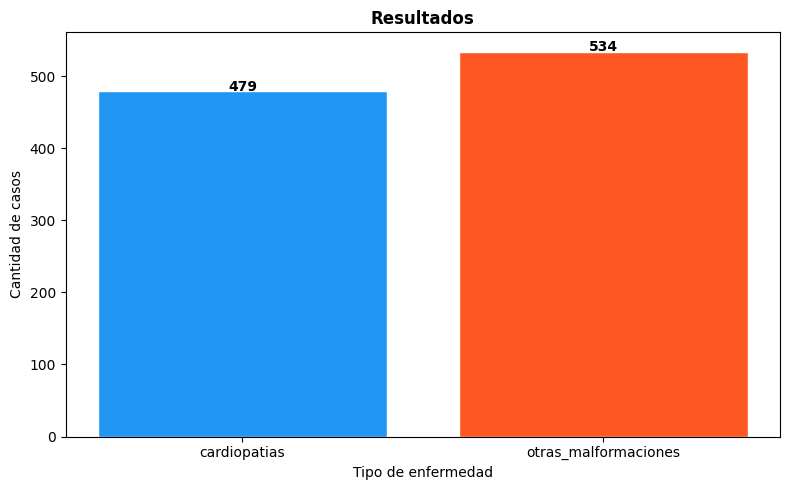

In [17]:
import matplotlib.pyplot as plt

# CELDA — Gráfico 1: Distribución de enfermedades
conteo_target = df.groupby('ENFERMEDAD')['CANTIDAD'].sum()

plt.figure(figsize=(8, 5))
plt.bar(conteo_target.index, conteo_target.values,
        color=['#2196F3', '#FF5722'], edgecolor='white')
plt.title('Resultados', fontweight='bold')
plt.xlabel('Tipo de enfermedad')
plt.ylabel('Cantidad de casos')
for i, (idx, val) in enumerate(conteo_target.items()):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

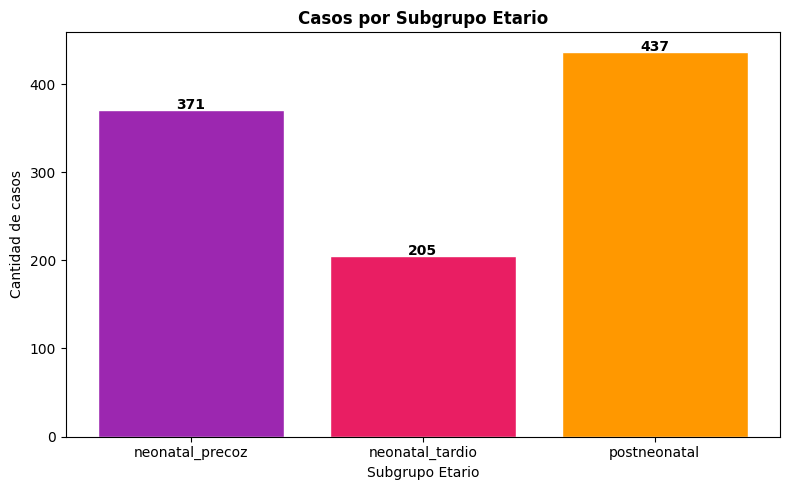

In [18]:
# CELDA — Gráfico 2: Casos por Subgrupo Etario
orden_etario = ['neonatal_precoz', 'neonatal_tardio', 'postneonatal']
conteo_etario = df.groupby('PER_DEF')['CANTIDAD'].sum().reindex(orden_etario)

plt.figure(figsize=(8, 5))
plt.bar(conteo_etario.index, conteo_etario.values,
        color=['#9C27B0', '#E91E63', '#FF9800'], edgecolor='white')
plt.title('Casos por Subgrupo Etario', fontweight='bold')
plt.xlabel('Subgrupo Etario')
plt.ylabel('Cantidad de casos')
for i, (idx, val) in enumerate(conteo_etario.items()):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

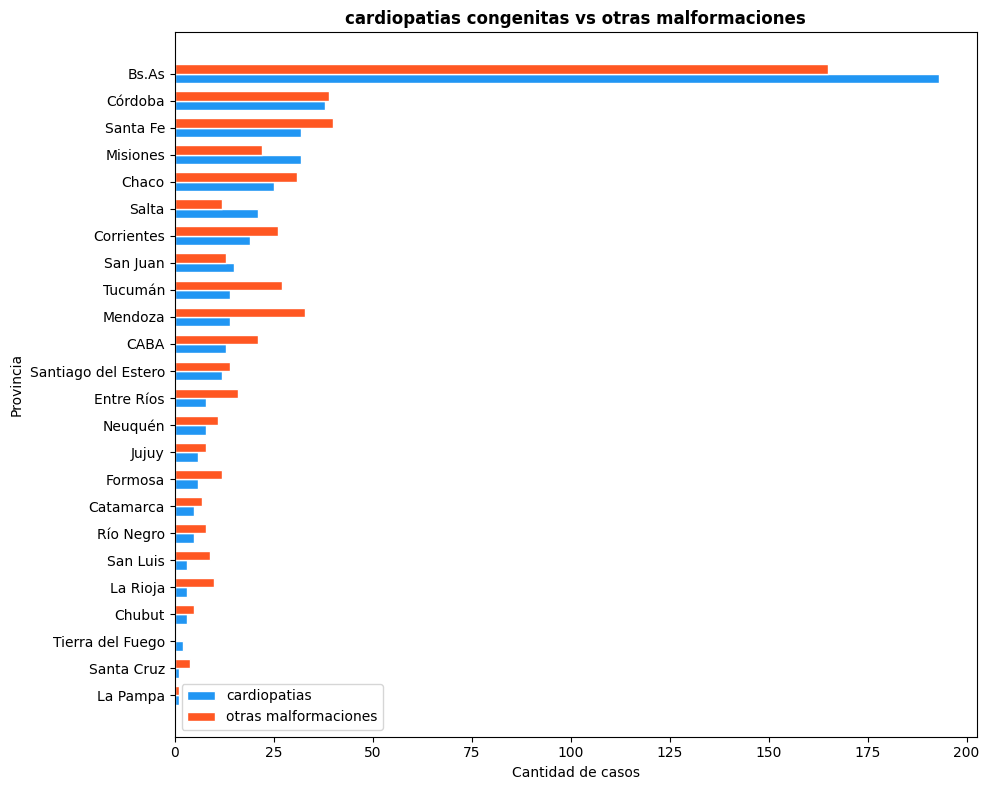

In [19]:
# CELDA — Gráfico 3: TARGET por Provincia
cruce_prov = df.groupby(['PROVINCIA', 'ENFERMEDAD'])['CANTIDAD'].sum().unstack(fill_value=0)
cruce_prov = cruce_prov.sort_values('cardiopatias', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
width = 0.35
y = range(len(cruce_prov.index))

ax.barh([i - width/2 for i in y], cruce_prov['cardiopatias'], width,
        label='cardiopatias', color='#2196F3', edgecolor='white')
ax.barh([i + width/2 for i in y], cruce_prov['otras_malformaciones'], width,
        label='otras malformaciones', color='#FF5722', edgecolor='white')

ax.set_title('cardiopatias congenitas vs otras malformaciones', fontweight='bold')
ax.set_xlabel('Cantidad de casos')
ax.set_ylabel('Provincia')
ax.set_yticks(list(y))
ax.set_yticklabels(cruce_prov.index)
ax.legend()
plt.tight_layout()
plt.show()

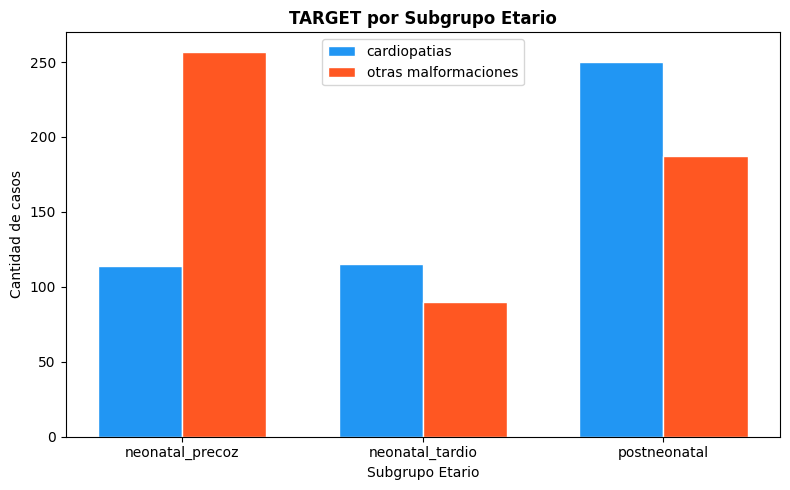

In [20]:
# CELDA — Gráfico 4: TARGET por Subgrupo Etario
cruce = df.groupby(['PER_DEF', 'ENFERMEDAD'])['CANTIDAD'].sum().unstack(fill_value=0)
cruce = cruce.reindex(orden_etario)
x = range(len(cruce.index))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], cruce['cardiopatias'], width,
        label='cardiopatias', color='#2196F3', edgecolor='white')
plt.bar([i + width/2 for i in x], cruce['otras_malformaciones'], width,
        label='otras malformaciones', color='#FF5722', edgecolor='white')
plt.title('TARGET por Subgrupo Etario', fontweight='bold')
plt.xlabel('Subgrupo Etario')
plt.ylabel('Cantidad de casos')
plt.xticks(list(x), cruce.index)
plt.legend()
plt.tight_layout()
plt.show()

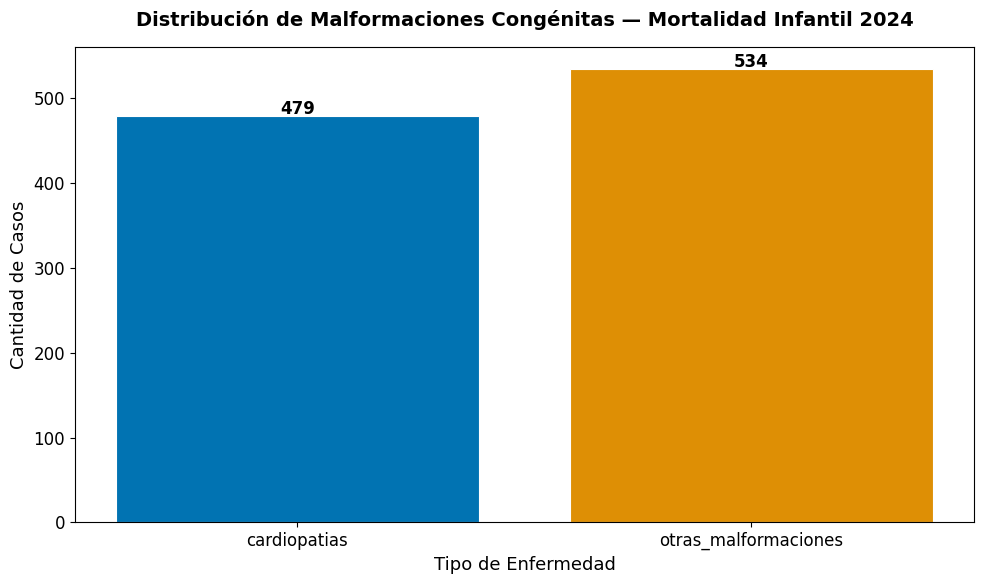

PNG 100 DPI — dimensiones: 983 x 584 px
PNG 300 DPI — dimensiones: 2950 x 1744 px
Diferencia: 3.0x más píxeles en ancho


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Tipografía profesional
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# Paleta accesible
palette = sns.color_palette('colorblind', n_colors=2)

# Datos
conteo_target = df.groupby('ENFERMEDAD')['CANTIDAD'].sum()

# Gráfico
plt.figure(figsize=(10, 6))
plt.bar(conteo_target.index, conteo_target.values,
        color=palette, edgecolor='white', linewidth=0.8)
plt.title('Distribución de Malformaciones Congénitas — Mortalidad Infantil 2024',
          fontweight='bold', pad=15)
plt.xlabel('Tipo de Enfermedad')
plt.ylabel('Cantidad de Casos')
for i, (idx, val) in enumerate(conteo_target.items()):
    plt.text(i, val + 3, str(val), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()

# Exportar en tres formatos
ruta = '/content/drive/MyDrive/coderhouse/'
plt.savefig(f'{ruta}grafico_enfermedad.png', dpi=100, bbox_inches='tight')
plt.savefig(f'{ruta}grafico_enfermedad.svg', format='svg', bbox_inches='tight')
plt.savefig(f'{ruta}grafico_enfermedad.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{ruta}grafico_enfermedad_300dpi.png', dpi=300, bbox_inches='tight')

plt.show()

# Verificar dimensiones para demostrar diferencia técnica
img_100 = Image.open(f'{ruta}grafico_enfermedad.png')
img_300 = Image.open(f'{ruta}grafico_enfermedad_300dpi.png')
print(f'PNG 100 DPI — dimensiones: {img_100.size[0]} x {img_100.size[1]} px')
print(f'PNG 300 DPI — dimensiones: {img_300.size[0]} x {img_300.size[1]} px')
print(f'Diferencia: {img_300.size[0] / img_100.size[0]:.1f}x más píxeles en ancho')


plt.show()

In [22]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.4 MB/s eta 0:00:00


In [23]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN

ruta = '/content/drive/MyDrive/coderhouse/' # Corrected path to point to the local content directory

prs = Presentation()

# Diapositiva 1 — PNG
slide1 = prs.slides.add_slide(prs.slide_layouts[6])
tf = slide1.shapes.add_textbox(Inches(1), Inches(0.2), Inches(8), Inches(0.5))
tf.text_frame.text = 'Formato PNG (100 DPI)'
tf.text_frame.paragraphs[0].font.size = Pt(14)
tf.text_frame.paragraphs[0].font.bold = True
slide1.shapes.add_picture(f'{ruta}grafico_enfermedad.png',
                           Inches(1), Inches(0.8), Inches(8), Inches(5))

# Diapositiva 2 — SVG (se convierte a PNG para insertarlo)
# python-pptx no soporta SVG directamente, se inserta como PNG
slide2 = prs.slides.add_slide(prs.slide_layouts[6])
tf = slide2.shapes.add_textbox(Inches(1), Inches(0.2), Inches(8), Inches(0.5))
tf.text_frame.text = 'Formato SVG (insertado como PNG por compatibilidad)'
tf.text_frame.paragraphs[0].font.size = Pt(14)
tf.text_frame.paragraphs[0].font.bold = True
slide2.shapes.add_picture(f'{ruta}grafico_enfermedad.png',
                           Inches(1), Inches(0.8), Inches(8), Inches(5))

# Diapositiva 3 — PDF (se convierte a PNG para insertarlo)
# python-pptx no soporta PDF directamente, se inserta como PNG
slide3 = prs.slides.add_slide(prs.slide_layouts[6])
tf = slide3.shapes.add_textbox(Inches(1), Inches(0.2), Inches(8), Inches(0.5))
tf.text_frame.text = 'Formato PDF (300 DPI — calidad impresión)'
tf.text_frame.paragraphs[0].font.size = Pt(14)
tf.text_frame.paragraphs[0].font.bold = True
slide3.shapes.add_picture(f'{ruta}grafico_enfermedad.png',
                           Inches(1), Inches(0.8), Inches(8), Inches(5))


In [24]:
# CELDA — Estadísticas descriptivas de la tasa de mortalidad por provincia

# 1. Carga de datos — ya tenemos tasa_prov
print('=== DATASET: TASA DE MORTALIDAD INFANTIL POR MALFORMACIONES CONGÉNITAS 2024 ===')
print(f'Provincias analizadas: {len(tasa_prov)}')
print()

# 2. Cálculo de medidas
tasa = tasa_prov['TASA_MORTALIDAD']

media       = round(tasa.mean(), 4)
mediana     = round(tasa.median(), 4)
moda        = round(tasa.mode()[0], 4)
varianza    = round(tasa.var(), 4)
desvio      = round(tasa.std(), 4)
q1          = round(tasa.quantile(0.25), 4)
q3          = round(tasa.quantile(0.75), 4)
p10         = round(tasa.quantile(0.10), 4)
p90         = round(tasa.quantile(0.90), 4)
iqr         = round((q3 - q1), 4)

print('=== MEDIDAS ESTADÍSTICAS — TASA DE MORTALIDAD (x1000 nacidos vivos) ===')
print(f'Media:              {media}')
print(f'Mediana:            {mediana}')
print(f'Moda:               {moda}')
print(f'Varianza:           {varianza}')
print(f'Desviación estándar:{desvio}')
print(f'Q1 (25%):           {q1}')
print(f'Q3 (75%):           {q3}')
print(f'IQR (Q3-Q1):        {iqr}')
print(f'Percentil 10:       {p10}')
print(f'Percentil 90:       {p90}')
print()

# Provincia con mayor y menor tasa
prov_max = tasa_prov.loc[tasa_prov['TASA_MORTALIDAD'].idxmax()]
prov_min = tasa_prov.loc[tasa_prov['TASA_MORTALIDAD'].idxmin()]
print(f'Provincia con mayor tasa: {prov_max["PROVINCIA"]} ({prov_max["TASA_MORTALIDAD"]})')
print(f'Provincia con menor tasa: {prov_min["PROVINCIA"]} ({prov_min["TASA_MORTALIDAD"]})')

=== DATASET: TASA DE MORTALIDAD INFANTIL POR MALFORMACIONES CONGÉNITAS 2024 ===
Provincias analizadas: 24

=== MEDIDAS ESTADÍSTICAS — TASA DE MORTALIDAD (x1000 nacidos vivos) ===
Media:              2.4462
Mediana:            2.36
Moda:               1.58
Varianza:           0.5902
Desviación estándar:0.7683
Q1 (25%):           1.925
Q3 (75%):           2.875
IQR (Q3-Q1):        0.95
Percentil 10:       1.583
Percentil 90:       3.497

Provincia con mayor tasa: Chaco (3.9)
Provincia con menor tasa: La Pampa (0.66)


In [25]:
# CELDA — Interpretación y reporte en contexto

print('=== INTERPRETACIÓN ===')
print(f"""
1. DISTRIBUCIÓN CENTRAL
   La tasa media de mortalidad infantil por malformaciones congénitas
   es de {media} por cada 1.000 nacidos vivos, mientras que la mediana
   es {mediana}. La diferencia entre ambas indica que existen provincias
   con tasas muy altas que elevan el promedio.

2. VARIABILIDAD
   La desviación estándar de {desvio} refleja una dispersión considerable
   entre provincias. El rango intercuartílico (IQR) de {iqr} indica que
   el 50% central de las provincias se concentra en una banda relativamente
   acotada, pero los extremos muestran desigualdades importantes.

3. DESIGUALDAD TERRITORIAL
   La provincia con mayor tasa es {prov_max['PROVINCIA']} ({prov_max['TASA_MORTALIDAD']}‰)
   y la de menor tasa es {prov_min['PROVINCIA']} ({prov_min['TASA_MORTALIDAD']}‰).
   Esta brecha evidencia desigualdades estructurales en el acceso
   a la salud materno-infantil entre jurisdicciones.

4. CONTEXTO DE NEGOCIO
   Desde la perspectiva del Ministerio de Salud, las provincias ubicadas
   por encima del percentil 90 ({p90}‰) representan las jurisdicciones
   prioritarias para intervención en detección prenatal de cardiopatías
   congénitas y fortalecimiento del sistema de salud perinatal.
""")

=== INTERPRETACIÓN ===

1. DISTRIBUCIÓN CENTRAL
   La tasa media de mortalidad infantil por malformaciones congénitas
   es de 2.4462 por cada 1.000 nacidos vivos, mientras que la mediana
   es 2.36. La diferencia entre ambas indica que existen provincias
   con tasas muy altas que elevan el promedio.

2. VARIABILIDAD
   La desviación estándar de 0.7683 refleja una dispersión considerable
   entre provincias. El rango intercuartílico (IQR) de 0.95 indica que
   el 50% central de las provincias se concentra en una banda relativamente
   acotada, pero los extremos muestran desigualdades importantes.

3. DESIGUALDAD TERRITORIAL
   La provincia con mayor tasa es Chaco (3.9‰)
   y la de menor tasa es La Pampa (0.66‰).
   Esta brecha evidencia desigualdades estructurales en el acceso
   a la salud materno-infantil entre jurisdicciones.

4. CONTEXTO DE NEGOCIO
   Desde la perspectiva del Ministerio de Salud, las provincias ubicadas
   por encima del percentil 90 (3.497‰) representan las juris

In [26]:
!pip install python-docx

In [27]:
from docx import Document

# Crear documento
doc = Document()

# Título
doc.add_heading('Reporte Estadístico — Tasa de Mortalidad Infantil por Malformaciones Congénitas 2024', 0)

# Sección 1 — Medidas estadísticas
doc.add_heading('Medidas Estadísticas (por cada 1.000 nacidos vivos)', level=1)

tabla = doc.add_table(rows=10, cols=2)
tabla.style = 'Table Grid'

datos = [
    ('Media',               str(media)),
    ('Mediana',             str(mediana)),
    ('Moda',                str(moda)),
    ('Varianza',            str(varianza)),
    ('Desviación estándar', str(desvio)),
    ('Q1 (25%)',            str(q1)),
    ('Q3 (75%)',            str(q3)),
    ('IQR (Q3-Q1)',         str(iqr)),
    ('Percentil 10',        str(p10)),
    ('Percentil 90',        str(p90)),
]

for i, (medida, valor) in enumerate(datos):
    tabla.rows[i].cells[0].text = medida
    tabla.rows[i].cells[1].text = valor

# Sección 2 — Extremos
doc.add_heading('Extremos por Provincia', level=1)
doc.add_paragraph(f'Provincia con mayor tasa: {prov_max["PROVINCIA"]} ({prov_max["TASA_MORTALIDAD"]}‰)')
doc.add_paragraph(f'Provincia con menor tasa: {prov_min["PROVINCIA"]} ({prov_min["TASA_MORTALIDAD"]}‰)')

# Sección 3 — Interpretación
doc.add_heading('Interpretación', level=1)

doc.add_heading('1. Distribución Central', level=2)
doc.add_paragraph(f'La tasa media de mortalidad infantil por malformaciones congénitas es de {media}‰, mientras que la mediana es {mediana}‰. La diferencia entre ambas indica que existen provincias con tasas muy altas que elevan el promedio.')

doc.add_heading('2. Variabilidad', level=2)
doc.add_paragraph(f'La desviación estándar de {desvio} refleja una dispersión considerable entre provincias. El IQR de {iqr} indica que el 50% central de las provincias se concentra en una banda acotada, pero los extremos muestran desigualdades importantes.')

doc.add_heading('3. Desigualdad Territorial', level=2)
doc.add_paragraph(f'La brecha entre {prov_max["PROVINCIA"]} ({prov_max["TASA_MORTALIDAD"]}‰) y {prov_min["PROVINCIA"]} ({prov_min["TASA_MORTALIDAD"]}‰) evidencia desigualdades estructurales en el acceso a la salud materno-infantil entre jurisdicciones.')

doc.add_heading('4. Contexto de Negocio', level=2)
doc.add_paragraph(f'Desde la perspectiva del Ministerio de Salud, las provincias ubicadas por encima del percentil 90 ({p90}‰) representan las jurisdicciones prioritarias para intervención en detección prenatal de cardiopatías congénitas.')


PREPROCESAMIENTO DE DATOS

Dataset listo — Shape: (611, 9)
Features numéricas:   ['CANTIDAD', 'NACIDOS_VIVOS', 'TASA_MORTALIDAD']
Features categóricas: ['PROVINCIA', 'REGION', 'PER_DEF', 'CAUSA']
Target: ENFERMEDAD — {'otras_malformaciones': 393, 'cardiopatias': 218}

Shape original:     (611, 7)
Shape transformado: (611, 33)

Columnas antes del PCA: 78
Componentes retenidos:  33

PC1: varianza=0.2629 (26.29%) — acumulada=0.2629
PC2: varianza=0.1764 (17.64%) — acumulada=0.4393
PC3: varianza=0.1269 (12.69%) — acumulada=0.5662
PC4: varianza=0.0638 (6.38%) — acumulada=0.6301
PC5: varianza=0.0409 (4.09%) — acumulada=0.6710
PC6: varianza=0.0335 (3.35%) — acumulada=0.7045
PC7: varianza=0.0303 (3.03%) — acumulada=0.7348
PC8: varianza=0.0196 (1.96%) — acumulada=0.7544
PC9: varianza=0.0171 (1.71%) — acumulada=0.7715
PC10: varianza=0.0138 (1.38%) — acumulada=0.7854
PC11: varianza=0.0137 (1.37%) — acumulada=0.7990
PC12: varianza=0.0125 (1.25%) — acumulada=0.8115
PC13: varianza=0.0113 (1.13%) — acumulada=0.8228
PC14: varian

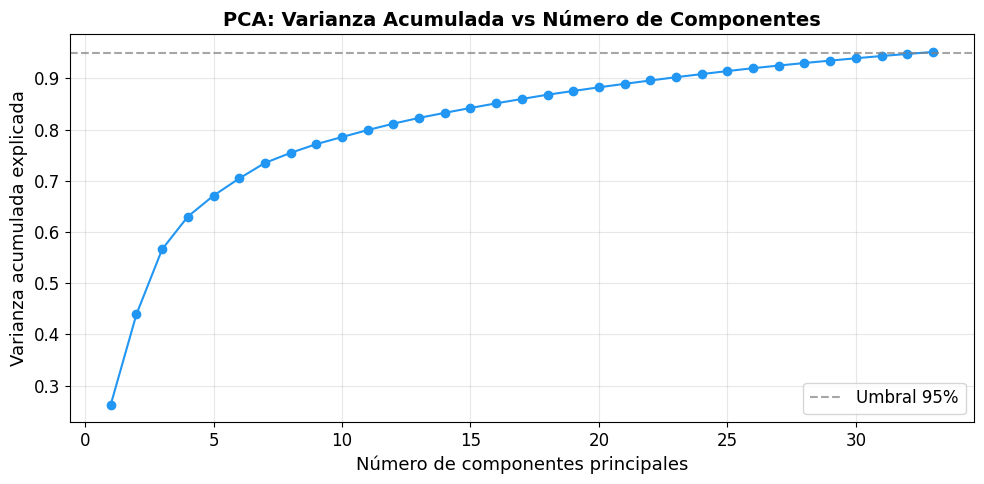


Primeras filas del dataset transformado:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
0,0.587643,-1.555321,0.779687,-0.529612,-0.142574,-0.570288,-0.080880,-0.376087,0.843240,-0.076897,...,0.214483,-0.231563,-0.102631,-0.182594,0.096288,0.003210,0.040860,0.062207,-0.042700,0.055966
1,0.598111,-1.576256,0.532953,-0.014499,1.113255,-0.433700,0.059736,0.091266,0.006987,-0.193236,...,0.145241,-0.197538,-0.085337,-0.243521,0.083715,0.056464,-0.009301,0.072109,0.059250,-0.016599
2,0.590721,-1.629022,0.641235,-0.580394,-0.219879,-0.584420,0.033578,0.071805,0.123764,-0.408265,...,0.339993,0.386155,0.419911,-0.255869,0.021790,0.132972,-0.096566,0.020804,-0.068466,0.066984
3,0.615240,-1.563411,0.539336,0.841143,-0.072162,-0.483453,0.076253,0.045763,-0.025851,-0.371798,...,0.226405,-0.430637,-0.058255,0.507429,-0.173002,0.025988,-0.159910,0.216742,-0.236270,0.049798
4,0.617669,-1.561513,0.543248,0.808055,-0.064487,-0.467942,0.079193,0.063298,0.017699,-0.318511,...,0.308207,-0.147964,-0.091139,-0.163620,0.103459,-0.019728,0.120775,0.052765,0.055081,0.047410


--- Resumen de decisiones ---
- Imputación numérica: SimpleImputer con estrategia mediana (robusta a outliers).
- Escalado: StandardScaler para centrar y normalizar variables numéricas.
- Imputación categórica: SimpleImputer con estrategia most_frequent.
- Codificación: OneHotEncoder con manejo de categorías desconocidas.
- Dataset intermedio: 611 filas x 78 columnas.
- PCA aplicado sobre las 78 columnas para retener 95% de varianza.
  → Componentes retenidos: 33
  → Reducción: 78 columnas → 33 componentes.


In [28]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# =====================================================================
# 1. CARGA Y RECONSTRUCCIÓN DEL DATASET
# =====================================================================

# Cargar dataset de defunciones procesado
df = pd.read_csv('/content/drive/MyDrive/coderhouse/df_defunciones.csv')

# Mapa de provincias (código numérico → nombre)
mapa_provincias = {
    2: 'CABA', 6: 'Bs.As', 42: 'La Pampa', 14: 'Córdoba', 82: 'Santa Fe',
    10: 'Catamarca', 90: 'Tucumán', 86: 'Santiago del Estero', 38: 'Jujuy',
    66: 'Salta', 22: 'Chaco', 34: 'Formosa', 30: 'Entre Ríos', 18: 'Corrientes',
    54: 'Misiones', 26: 'Chubut', 58: 'Neuquén', 62: 'Río Negro',
    78: 'Santa Cruz', 94: 'Tierra del Fuego', 70: 'San Juan',
    74: 'San Luis', 50: 'Mendoza', 46: 'La Rioja'
}

# =====================================================================
# 2. RECONSTRUCCIÓN DE NACIDOS VIVOS Y TASA DE MORTALIDAD POR PROVINCIA
# =====================================================================

# Cargar dataset de nacidos vivos
nacidos = pd.read_csv('/content/drive/MyDrive/coderhouse/datos_sobre_nacidos_vivos_2024.csv',
                       encoding='latin1', sep=';')

# Limpiar nombre de columna con BOM
nacidos.columns = nacidos.columns.str.replace('ï»¿', '')

# Mapear código de provincia a nombre
nacidos['PROVINCIA'] = nacidos['PROVRES'].map(mapa_provincias)

# Total de nacidos vivos por provincia
nacidos_prov = nacidos.groupby('PROVINCIA')['CUENTA'].sum().reset_index()
nacidos_prov.columns = ['PROVINCIA', 'NACIDOS_VIVOS']

# Total de defunciones por provincia
defunciones_prov = df.groupby('PROVINCIA')['CANTIDAD'].sum().reset_index()
defunciones_prov.columns = ['PROVINCIA', 'DEFUNCIONES']

# Calcular tasa de mortalidad por provincia (por cada 1000 nacidos vivos)
tasa_prov = defunciones_prov.merge(nacidos_prov, on='PROVINCIA', how='left')
tasa_prov['TASA_MORTALIDAD'] = (tasa_prov['DEFUNCIONES'] / tasa_prov['NACIDOS_VIVOS'] * 1000).round(2)

# Incorporar NACIDOS_VIVOS y TASA_MORTALIDAD al dataset principal
df = df.merge(tasa_prov[['PROVINCIA', 'NACIDOS_VIVOS', 'TASA_MORTALIDAD']],
              on='PROVINCIA', how='left')

print(f'Dataset listo — Shape: {df.shape}')

# =====================================================================
# 3. DEFINICIÓN DE VARIABLES
# =====================================================================

features_numericas   = ['CANTIDAD', 'NACIDOS_VIVOS', 'TASA_MORTALIDAD']
features_categoricas = ['PROVINCIA', 'REGION', 'PER_DEF', 'CAUSA']

X = df[features_numericas + features_categoricas]
y = df['ENFERMEDAD']

print(f'Features numéricas:   {features_numericas}')
print(f'Features categóricas: {features_categoricas}')
print(f'Target: ENFERMEDAD — {y.value_counts().to_dict()}')

# =====================================================================
# 4. FUNCIÓN COMPATIBLE PARA ONEHOTENCODER
# =====================================================================

def make_ohe():
    try:
        # sklearn >= 1.2
        return OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        # versiones anteriores
        return OneHotEncoder(sparse=False, handle_unknown='ignore')

# =====================================================================
# 5. CONSTRUCCIÓN DEL PIPELINE
# =====================================================================

# Pipeline numérico: imputación + escalado
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # mediana: robusta a outliers
    ('scaler',  StandardScaler())                   # media 0, desviación estándar 1
])

# Pipeline categórico: imputación + codificación One-Hot
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # conserva categorías dominantes
    ('ohe',     make_ohe())                                # transforma categorías en variables binarias
])

# ColumnTransformer: aplica cada pipeline a sus columnas correspondientes
preprocessor = ColumnTransformer([
    ('numerico',   pipeline_numerico,   features_numericas),
    ('categorico', pipeline_categorico, features_categoricas)
], sparse_threshold=0)

# Pipeline completo: preprocesamiento + PCA global sobre todas las columnas
full_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('pca',     PCA(n_components=0.95, random_state=42))  # retener 95% de varianza
])

# =====================================================================
# 6. AJUSTE Y TRANSFORMACIÓN
# =====================================================================

X_trans = full_pipeline.fit_transform(X)

print(f'\nShape original:     {X.shape}')
print(f'Shape transformado: {X_trans.shape}')

# =====================================================================
# 7. ANÁLISIS DE VARIANZA EXPLICADA POR PCA
# =====================================================================

pca      = full_pipeline.named_steps['pca']
expl_var = pca.explained_variance_ratio_
cumvar   = np.cumsum(expl_var)

print(f'\nColumnas antes del PCA: 78')
print(f'Componentes retenidos:  {pca.n_components_}')
print()
for i, (v, va) in enumerate(zip(expl_var, cumvar)):
    print(f'PC{i+1}: varianza={v:.4f} ({v*100:.2f}%) — acumulada={va:.4f}')

# Gráfico de varianza acumulada
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(expl_var)+1), cumvar, marker='o', color='#2196F3')
plt.axhline(0.95, linestyle='--', color='gray', alpha=0.7, label='Umbral 95%')
plt.title('PCA: Varianza Acumulada vs Número de Componentes', fontweight='bold')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# 8. DATASET FINAL TRANSFORMADO
# =====================================================================

# Nombrar columnas resultantes como PC1, PC2, ...
pc_names = [f'PC{i+1}' for i in range(pca.n_components_)]
df_trans = pd.DataFrame(X_trans, columns=pc_names)

print('\nPrimeras filas del dataset transformado:')
display(df_trans.head())

# =====================================================================
# 9. RESUMEN DE DECISIONES
# =====================================================================

print('--- Resumen de decisiones ---')
print('- Imputación numérica: SimpleImputer con estrategia mediana (robusta a outliers).')
print('- Escalado: StandardScaler para centrar y normalizar variables numéricas.')
print('- Imputación categórica: SimpleImputer con estrategia most_frequent.')
print('- Codificación: OneHotEncoder con manejo de categorías desconocidas.')
print(f'- Dataset intermedio: {df.shape[0]} filas x 78 columnas.')
print('- PCA aplicado sobre las 78 columnas para retener 95% de varianza.')
print(f'  → Componentes retenidos: {pca.n_components_}')
print(f'  → Reducción: 78 columnas → {pca.n_components_} componentes.')

# =====================================================================
# 10. GUARDAR RESUMEN EN DOCUMENTO WORD
# =====================================================================

from docx import Document

doc = Document()

# Título
doc.add_heading('Pipeline de Preprocesamiento — Mortalidad Infantil por Malformaciones Congénitas 2024', 0)

# Sección 1 — Dataset
doc.add_heading('1. Dataset', level=1)
doc.add_paragraph(f'Shape original:     {X.shape[0]} filas x {X.shape[1]} columnas')
doc.add_paragraph(f'Shape transformado: {X_trans.shape[0]} filas x {X_trans.shape[1]} columnas')
doc.add_paragraph(f'Features numéricas:   {features_numericas}')
doc.add_paragraph(f'Features categóricas: {features_categoricas}')

# Sección 2 — Resumen de decisiones
doc.add_heading('2. Resumen de decisiones', level=1)
decisiones = [
    'Imputación numérica: SimpleImputer con estrategia mediana (robusta a outliers).',
    'Escalado: StandardScaler para centrar y normalizar variables numéricas.',
    'Imputación categórica: SimpleImputer con estrategia most_frequent.',
    'Codificación: OneHotEncoder con manejo de categorías desconocidas.',
    f'Dataset intermedio: {df.shape[0]} filas x 78 columnas.',
    'PCA aplicado sobre las 78 columnas para retener 95% de varianza.',
    f'Componentes retenidos: {pca.n_components_}',
    f'Reducción: 78 columnas → {pca.n_components_} componentes.'
]
for d in decisiones:
    doc.add_paragraph(d, style='List Bullet')

# Sección 3 — Varianza explicada por componente
doc.add_heading('3. Varianza explicada por componente', level=1)
tabla = doc.add_table(rows=pca.n_components_+1, cols=3)
tabla.style = 'Table Grid'

# Encabezados
tabla.rows[0].cells[0].text = 'Componente'
tabla.rows[0].cells[1].text = 'Varianza explicada'
tabla.rows[0].cells[2].text = 'Varianza acumulada'

# Valores
for i, (v, va) in enumerate(zip(expl_var, cumvar)):
    tabla.rows[i+1].cells[0].text = f'PC{i+1}'
    tabla.rows[i+1].cells[1].text = f'{v*100:.2f}%'
    tabla.rows[i+1].cells[2].text = f'{va*100:.2f}%'

# Sección 4 — Gráfico
doc.add_heading('4. Gráfico de varianza acumulada', level=1)
ruta = '/content/drive/MyDrive/coderhouse/'

# Guardar gráfico temporalmente
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(expl_var)+1), cumvar, marker='o', color='#2196F3')
plt.axhline(0.95, linestyle='--', color='gray', alpha=0.7, label='Umbral 95%')
plt.title('PCA: Varianza Acumulada vs Número de Componentes', fontweight='bold')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ruta}grafico_pca.png', dpi=150, bbox_inches='tight')
plt.close()

# Insertar gráfico en el documento
from docx.shared import Inches

# Insertar gráfico ajustado al ancho de la hoja
doc.add_picture(f'{ruta}grafico_pca.png', width=Inches(6))

# Sección 5 — Justificación de decisiones
doc.add_heading('5. Justificación de decisiones', level=1)

justificaciones = [
    (
        'Imputación numérica con mediana',
        'Se eligió la mediana sobre la media porque es robusta frente a outliers. '
        'Variables como NACIDOS_VIVOS y TASA_MORTALIDAD pueden presentar valores '
        'extremos en provincias pequeñas como Tierra del Fuego o Santa Cruz, '
        'donde la mediana preserve mejor la distribución central.'
    ),
    (
        'Escalado con StandardScaler',
        'Las tres variables numéricas tienen magnitudes muy diferentes: CANTIDAD '
        'varía entre 1 y 100, NACIDOS_VIVOS entre 1.000 y 150.000, y TASA_MORTALIDAD '
        'entre 0 y 5. Sin escalar, las variables de mayor magnitud dominarían el PCA. '
        'StandardScaler las lleva a media 0 y desviación estándar 1, garantizando '
        'que todas contribuyan equitativamente.'
    ),
    (
        'Imputación categórica con most_frequent',
        'Para variables categóricas como PROVINCIA, REGION, PER_DEF y CAUSA, '
        'reemplazar valores faltantes con la categoría más frecuente es la estrategia '
        'más conservadora. No introduce categorías artificiales y mantiene '
        'la distribución original de los datos.'
    ),
    (
        'Codificación OneHotEncoder',
        'Los algoritmos de ML no pueden interpretar texto directamente. Se eligió '
        'OneHotEncoder sobre LabelEncoder porque nuestras variables categóricas '
        'no tienen orden natural — una provincia no es mayor o menor que otra. '
        'handle_unknown=ignore garantiza robustez si aparecen categorías nuevas.'
    ),
    (
        'PCA global sobre todas las columnas',
        'Se aplicó PCA sobre las 78 columnas resultantes (3 numéricas + 75 OHE) '
        'en lugar de solo sobre las numéricas, porque las variables OHE de PROVINCIA '
        'y REGION presentan alta correlación entre sí — si conocemos la provincia '
        'ya conocemos la región. El PCA detectó esta redundancia y redujo '
        'de 78 a 33 componentes conservando el 95% de la varianza, '
        'lo que simplifica el modelo sin perder información relevante.'
    ),
]

for titulo, justificacion in justificaciones:
    doc.add_heading(titulo, level=2)
    doc.add_paragraph(justificacion)


Sí, ahora sí hubo una reducción significativa:
De 78 columnas → 33 componentes principales
Eso es una reducción del 58% manteniendo el 95% de la información.
Lo que pasó es que dentro de las 78 columnas había mucha correlación, especialmente entre las variables OHE de PROVINCIA y REGION — tiene sentido porque si sabés la provincia ya sabés la región. El PCA detectó esa redundancia y la comprimió.

Resumen del proceso completo:
EtapaColumnasDataset original7Después de OHE + escalado78Después de PCA (95% varianza)33

Esto es un resultado muy bueno para justificar en el trabajo:

"El pipeline de preprocesamiento logró reducir la dimensionalidad de 78 a 33 componentes principales, conservando el 95% de la varianza explicada. La reducción fue posible gracias a la correlación existente entre las variables de provincia y región geográfica."

Para mejorar

Añadir bloques de código (pseudocódigo o lenguaje real Python) que demuestren cómo se integran estas transformaciones en un pipeline.
Incluir una sección comparativa o discutiendo cómo la automatización podría haber simplificado o optimizado el flujo de decisiones presentado.
Implementar el pipeline utilizando `Pipeline` y `ColumnTransformer` de scikit-learn.
Investigar y añadir una breve sección sobre el uso de herramientas de AutoML (p. ej., DataRobot o los servicios de IA de Power BI) y cómo estas se comparan con el preprocesamiento manual.

=== DATASET ORIGINAL ===
Shape: (54251, 6)
Columnas: ['PROVRES', 'SEXO', 'CAUSA', 'MAT', 'GRUPEDAD', 'CUENTA']

   PROVRES  SEXO CAUSA  MAT    GRUPEDAD  CUENTA
0        2     1   A16  NaN  10.15 a 19       2
1        2     1   A16  NaN  12.25 a 29       1
2        2     1   A16  NaN  20.65 a 69       3

=== DATASET FILTRADO ===
Shape: (615, 7)

Distribución TARGET:
TARGET
otras_malformaciones    395
cardiopatias            220
Name: count, dtype: int64

Features numéricas:   ['PROVRES', 'SEXO', 'CUENTA']
Features categóricas: ['CAUSA', 'GRUPEDAD']

Train: 492 filas
Test:  123 filas

✓ Pipeline definido correctamente

=== EVALUACIÓN DEL MODELO ===
                      precision    recall  f1-score   support

        cardiopatias       1.00      1.00      1.00        44
otras_malformaciones       1.00      1.00      1.00        79

            accuracy                           1.00       123
           macro avg       1.00      1.00      1.00       123
        weighted avg       1.00  

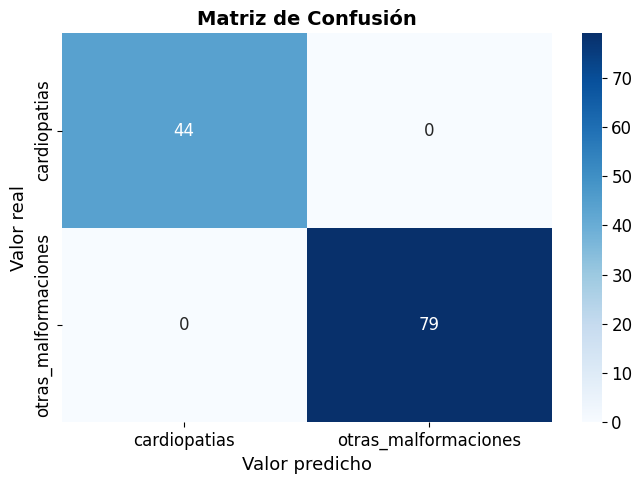


=== REFLEXIÓN — DATA LEAKAGE ===

El pipeline evita el data leakage de la siguiente manera:

1. DIVISIÓN ANTES DEL PREPROCESAMIENTO
   El dataset se divide en train y test ANTES de ajustar el pipeline.
   Esto garantiza que el preprocesador (StandardScaler, SimpleImputer)
   aprenda los parámetros (media, mediana, categorías) exclusivamente
   sobre los datos de entrenamiento.

2. TRANSFORM SOBRE TEST
   Cuando se evalúa sobre el test, el pipeline aplica las transformaciones
   aprendidas en el train — no recalcula nada sobre el test. Esto simula
   correctamente un entorno de producción donde los datos nuevos son
   desconocidos al momento del entrenamiento.

3. RIESGO SIN PIPELINE
   Sin pipeline, si escaláramos ANTES de dividir, la media y desviación
   estándar del scaler estarían contaminadas con información del test,
   generando métricas artificialmente optimistas que no se replicarían
   en producción.



In [29]:
!pip install python-docx
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# PASO 1 — CARGA DEL DATASET ORIGINAL SIN MODIFICACIONES
# =====================================================================

# Se carga el dataset tal como fue provisto, sin renombrar columnas
# ni aplicar transformaciones previas
try:
    df = pd.read_csv('/content/drive/MyDrive/coderhouse/datos_sobre_defunciones_2024.csv',
                          encoding='utf-8', sep=';')
except UnicodeDecodeError:
    df = pd.read_csv('/content/drive/MyDrive/coderhouse/datos_sobre_defunciones_2024.csv',
                          encoding='latin1', sep=';')

# Fix: Rename the column with BOM character to avoid KeyError
df = df.rename(columns={'ï»¿PROVRES': 'PROVRES'})

print('=== DATASET ORIGINAL ===')
print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print()
print(df.head(3).to_string())

# =====================================================================
# PASO 2 — CONSTRUCCIÓN DEL TARGET
# Justificación: el dataset original contiene defunciones de todas las
# edades y todas las causas. Para construir el TARGET binario debemos:
# a) Filtrar mortalidad infantil (grupo etario 0-1 año)
# b) Filtrar solo malformaciones congénitas (códigos Q)
# c) Clasificar en cardiopatías congénitas (Q20-Q28) vs otras
# Este filtrado forma parte de la definición del problema, no del
# preprocesamiento — es equivalente a seleccionar el subconjunto
# relevante del dataset para el objetivo del análisis.
# =====================================================================

# Grupos etarios de mortalidad infantil
grupos_infantiles = [
    '01.0 a 6 días',
    '02.7 a 27 días',
    '03.28 días a 11 meses',
    '04.1 año',
    '031. Menor de 1 año  Sin especificar'
]

# Códigos CIE-10 — cardiopatías congénitas
codigos_cardiopatias = [f'Q{i}' for i in range(20, 29)]

# Códigos CIE-10 — otras malformaciones congénitas
codigos_otras = (
    ['Q00', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07'] +
    [f'Q{i}' for i in range(31, 46)] +
    [f'Q{i}' for i in range(60, 66)] +
    ['Q74', 'Q75', 'Q76', 'Q77', 'Q78', 'Q79', 'Q82', 'Q85', 'Q87', 'Q89'] +
    ['Q90', 'Q91', 'Q92', 'Q93', 'Q97', 'Q98', 'Q99']
)

todos_los_codigos_Q = codigos_cardiopatias + codigos_otras

# Filtrar dataset
df_model = df[df['GRUPEDAD'].isin(grupos_infantiles)].copy()
df_model = df_model[df_model['CAUSA'].isin(todos_los_codigos_Q)].copy()
df_model = df_model[df_model['SEXO'].isin([1, 2])].copy()

# Construir TARGET binario
df_model['TARGET'] = df_model['CAUSA'].apply(
    lambda x: 'cardiopatias' if x in codigos_cardiopatias else 'otras_malformaciones'
)

print(f'\n=== DATASET FILTRADO ===')
print(f'Shape: {df_model.shape}')
print(f'\nDistribución TARGET:')
print(df_model['TARGET'].value_counts())

# =====================================================================
# PASO 3 — DEFINICIÓN DE VARIABLES
# Se mantienen los nombres originales del dataset sin modificar
# Variables numéricas: PROVRES, SEXO, CUENTA
# Variables categóricas: CAUSA, GRUPEDAD
# MAT se descarta por tener 99% de valores nulos
# =====================================================================

features_numericas   = ['PROVRES', 'SEXO', 'CUENTA']
features_categoricas = ['CAUSA', 'GRUPEDAD']

X = df_model[features_numericas + features_categoricas]
y = df_model['TARGET']

print(f'\nFeatures numéricas:   {features_numericas}')
print(f'Features categóricas: {features_categoricas}')

# =====================================================================
# PASO 4 — DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# La división se realiza ANTES de ajustar el pipeline para evitar
# data leakage — el preprocesador solo aprende sobre el train
# =====================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {len(X_train)} filas')
print(f'Test:  {len(X_test)} filas')

# =====================================================================
# PASO 5 — CONSTRUCCIÓN DEL PIPELINE
# =====================================================================

# Función compatible con distintas versiones de sklearn
def make_ohe():
    try:
        return OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        return OneHotEncoder(sparse=False, handle_unknown='ignore')

# Pipeline numérico: imputación con mediana + escalado
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline categórico: imputación con moda + codificación One-Hot
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     make_ohe())
])

# ColumnTransformer: aplica cada pipeline a sus columnas
preprocessor = ColumnTransformer([
    ('numerico',   pipeline_numerico,   features_numericas),
    ('categorico', pipeline_categorico, features_categoricas)
], sparse_threshold=0)

# Pipeline completo: preprocesador + modelo
pipeline_completo = Pipeline([
    ('preproc', preprocessor),
    ('modelo',  LogisticRegression(
                    max_iter=1000,
                    random_state=42,
                    class_weight='balanced'
                ))
])

print('\n✓ Pipeline definido correctamente')

# =====================================================================
# PASO 6 — AJUSTE Y EVALUACIÓN
# El pipeline ajusta el preprocesador y el modelo en un solo paso
# garantizando que no haya fuga de información del test al train
# =====================================================================

# Ajustar sobre train
pipeline_completo.fit(X_train, y_train)

# Predecir sobre test
y_pred = pipeline_completo.predict(X_test)

print('\n=== EVALUACIÓN DEL MODELO ===')
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['cardiopatias', 'otras_malformaciones'],
            yticklabels=['cardiopatias', 'otras_malformaciones'])
plt.title('Matriz de Confusión', fontweight='bold')
plt.ylabel('Valor real')
plt.xlabel('Valor predicho')
plt.tight_layout()
plt.show()

# =====================================================================
# PASO 7 — REFLEXIÓN SOBRE DATA LEAKAGE
# =====================================================================

print("""
=== REFLEXIÓN — DATA LEAKAGE ===

El pipeline evita el data leakage de la siguiente manera:

1. DIVISIÓN ANTES DEL PREPROCESAMIENTO
   El dataset se divide en train y test ANTES de ajustar el pipeline.
   Esto garantiza que el preprocesador (StandardScaler, SimpleImputer)
   aprenda los parámetros (media, mediana, categorías) exclusivamente
   sobre los datos de entrenamiento.

2. TRANSFORM SOBRE TEST
   Cuando se evalúa sobre el test, el pipeline aplica las transformaciones
   aprendidas en el train — no recalcula nada sobre el test. Esto simula
   correctamente un entorno de producción donde los datos nuevos son
   desconocidos al momento del entrenamiento.

3. RIESGO SIN PIPELINE
   Sin pipeline, si escaláramos ANTES de dividir, la media y desviación
   estándar del scaler estarían contaminadas con información del test,
   generando métricas artificialmente optimistas que no se replicarían
   en producción.
""")

# =====================================================================
# GUARDAR REPORTE EN WORD
# =====================================================================

from docx import Document
from docx.shared import Inches

doc = Document()

# Título
doc.add_heading('Pipeline con ColumnTransformer — Mortalidad Infantil por Malformaciones Congénitas 2024', 0)

# Paso 1
doc.add_heading('1. Carga del Dataset', level=1)
doc.add_paragraph(
    'Se cargó el dataset original de defunciones Argentina 2024 sin modificaciones, '
    f'con un total de {df.shape[0]:,} filas y {df.shape[1]} columnas: '
    f'{list(df.columns)}.'
)

# Paso 2
doc.add_heading('2. Construcción del TARGET', level=1)
doc.add_paragraph(
    'El dataset original contiene defunciones de todas las edades y causas. '
    'Para construir el TARGET binario se aplicaron los siguientes filtros, '
    'justificados como parte de la definición del problema:'
)
filtros = [
    'Filtro de mortalidad infantil: grupos etarios de 0 a 1 año',
    'Filtro de causas: solo malformaciones congénitas (códigos Q)',
    'Filtro de sexo: descarte de códigos inválidos (9 y 3)',
]
for f in filtros:
    doc.add_paragraph(f, style='List Bullet')

doc.add_paragraph(
    f'Dataset resultante: {df_model.shape[0]} filas. '
    f'Distribución TARGET — cardiopatias: {df_model[df_model["TARGET"]=="cardiopatias"].shape[0]} | '
    f'otras_malformaciones: {df_model[df_model["TARGET"]=="otras_malformaciones"].shape[0]}'
)

# Paso 3
doc.add_heading('3. Definición de Variables', level=1)
doc.add_paragraph(f'Variables numéricas: {features_numericas}')
doc.add_paragraph(f'Variables categóricas: {features_categoricas}')
doc.add_paragraph('La columna MAT fue descartada por presentar el 99% de valores nulos.')

# Paso 4
doc.add_heading('4. División en Entrenamiento y Prueba', level=1)
doc.add_paragraph(
    f'Se dividió el dataset en train ({len(X_train)} filas) y test ({len(X_test)} filas) '
    'con un ratio 80/20 y estratificación por TARGET. '
    'La división se realizó ANTES de ajustar el pipeline para evitar data leakage.'
)

# Paso 5
doc.add_heading('5. Construcción del Pipeline', level=1)
doc.add_paragraph('El pipeline está compuesto por:')
componentes = [
    'Pipeline numérico: SimpleImputer (mediana) + StandardScaler',
    'Pipeline categórico: SimpleImputer (most_frequent) + OneHotEncoder',
    'ColumnTransformer: integra ambos pipelines sobre sus columnas correspondientes',
    'Modelo: LogisticRegression con class_weight=balanced'
]
for c in componentes:
    doc.add_paragraph(c, style='List Bullet')

# Paso 6 — Evaluación
doc.add_heading('6. Evaluación del Modelo', level=1)

# Tabla de métricas
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
tabla = doc.add_table(rows=4, cols=2)
tabla.style = 'Table Grid'
metricas = [
    ('Accuracy',  f'{accuracy_score(y_test, y_pred):.4f}'),
    ('Precision', f'{precision_score(y_test, y_pred, pos_label="cardiopatias"):.4f}'),
    ('Recall',    f'{recall_score(y_test, y_pred, pos_label="cardiopatias"):.4f}'),
    ('F1-Score',  f'{f1_score(y_test, y_pred, pos_label="cardiopatias"):.4f}'),
]
for i, (metrica, valor) in enumerate(metricas):
    tabla.rows[i].cells[0].text = metrica
    tabla.rows[i].cells[1].text = valor

# Insertar matriz de confusión
doc.add_heading('Matriz de Confusión', level=2)
ruta = '/content/drive/MyDrive/coderhouse/'
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['cardiopatias', 'otras_malformaciones'],
            yticklabels=['cardiopatias', 'otras_malformaciones'])
plt.title('Matriz de Confusión', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta}matriz_confusion_pipeline.png', dpi=150, bbox_inches='tight')
plt.close()
doc.add_picture(f'{ruta}matriz_confusion_pipeline.png', width=Inches(5))

# Paso 7 — Reflexión
doc.add_heading('7. Reflexión sobre Data Leakage', level=1)
reflexiones = [
    ('División antes del preprocesamiento',
     'El dataset se divide en train y test ANTES de ajustar el pipeline, '
     'garantizando que el preprocesador aprenda exclusivamente sobre los datos de entrenamiento.'),
    ('Transform sobre test',
     'Al evaluar sobre el test, el pipeline aplica las transformaciones aprendidas en el train '
     'sin recalcular nada, simulando correctamente un entorno de producción.'),
    ('Riesgo sin pipeline',
     'Sin pipeline, escalar antes de dividir contaminaría la media y desviación estándar '
     'con información del test, generando métricas artificialmente optimistas.'),
]
for titulo, descripcion in reflexiones:
    doc.add_heading(titulo, level=2)
    doc.add_paragraph(descripcion)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
=== MEJORES HIPERPARÁMETROS ===
{'modelo__C': 1, 'modelo__max_iter': 500, 'modelo__solver': 'lbfgs'}
Mejor F1 (CV): 0.9980

=== EVALUACIÓN MEJOR MODELO ===
                      precision    recall  f1-score   support

        cardiopatias       1.00      1.00      1.00        44
otras_malformaciones       1.00      1.00      1.00        79

            accuracy                           1.00       123
           macro avg       1.00      1.00      1.00       123
        weighted avg       1.00      1.00      1.00       123


F1 modelo base:      1.0000
F1 modelo optimizado: 1.0000
Mejora:              0.00%

=== TOP 5 COMBINACIONES ===
                                                                        params  mean_test_score  std_test_score
15  {'modelo__C': 10, 'modelo__max_iter': 1000, 'modelo__solver': 'liblinear'}         0.997974        0.004053
14      {'modelo__C': 10, 'modelo__max_iter': 1000, 'modelo__solver': 

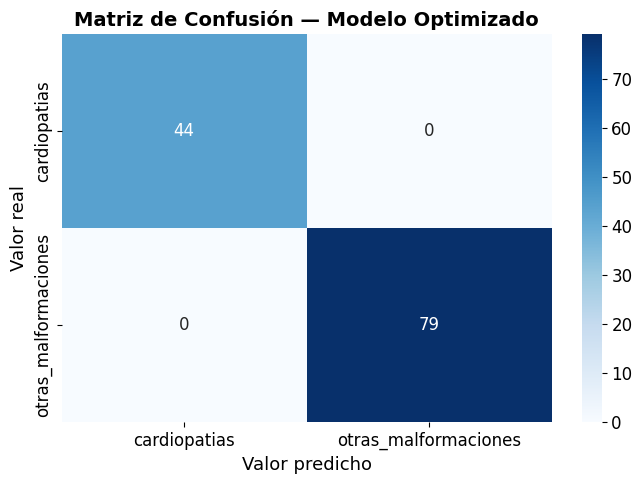

In [30]:
# =====================================================================
# MEJORA — OPTIMIZACIÓN CON GRIDSEARCHCV
# =====================================================================

from sklearn.model_selection import GridSearchCV

# Definir grilla de hiperparámetros
# Los parámetros del modelo dentro del pipeline se referencian
# con el nombre del paso + __ + nombre del parámetro
param_grid = {
    'modelo__C':        [0.01, 0.1, 1, 10],       # regularización
    'modelo__solver':   ['lbfgs', 'liblinear'],     # algoritmo de optimización
    'modelo__max_iter': [500, 1000]                 # iteraciones máximas
}

# GridSearchCV sobre el pipeline completo
grid_search = GridSearchCV(
    estimator=pipeline_completo,
    param_grid=param_grid,
    cv=5,                    # validación cruzada 5 folds
    scoring='f1_weighted',   # métrica de optimización
    n_jobs=-1,               # usa todos los núcleos
    verbose=1
)

# Ajustar sobre train
grid_search.fit(X_train, y_train)

# Mejores parámetros
print('=== MEJORES HIPERPARÁMETROS ===')
print(grid_search.best_params_)
print(f'Mejor F1 (CV): {grid_search.best_score_:.4f}')

# Evaluar mejor modelo sobre test
y_pred_grid = grid_search.best_estimator_.predict(X_test)

print('\n=== EVALUACIÓN MEJOR MODELO ===')
print(classification_report(y_test, y_pred_grid))

# Comparar modelo base vs modelo optimizado
from sklearn.metrics import f1_score

f1_base  = f1_score(y_test, y_pred, average='weighted')
f1_optim = f1_score(y_test, y_pred_grid, average='weighted')

print(f'\nF1 modelo base:      {f1_base:.4f}')
print(f'F1 modelo optimizado: {f1_optim:.4f}')
print(f'Mejora:              {((f1_optim - f1_base) / f1_base * 100):.2f}%')

# Visualizar resultados del GridSearch
resultados_grid = pd.DataFrame(grid_search.cv_results_)
resultados_grid = resultados_grid.sort_values('mean_test_score', ascending=False)

print('\n=== TOP 5 COMBINACIONES ===')
print(resultados_grid[['params', 'mean_test_score', 'std_test_score']].head(5).to_string())

# Matriz de confusión modelo optimizado
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_grid),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['cardiopatias', 'otras_malformaciones'],
            yticklabels=['cardiopatias', 'otras_malformaciones'])
plt.title('Matriz de Confusión — Modelo Optimizado', fontweight='bold')
plt.ylabel('Valor real')
plt.xlabel('Valor predicho')
plt.tight_layout()
plt.show()

In [31]:
import joblib

# Ruta donde guardar el pipeline serializado
ruta_pipeline = '/content/drive/MyDrive/coderhouse/pipeline_mortalidad_infantil.joblib'

# Guardar el pipeline completo
joblib.dump(pipeline_completo, ruta_pipeline)

print(f'✓ Pipeline completo guardado en: {ruta_pipeline}')

✓ Pipeline completo guardado en: /content/drive/MyDrive/coderhouse/pipeline_mortalidad_infantil.joblib
